In [58]:
import pandas as pd
import os
pd.set_option("display.max_columns", None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calmap


In [59]:
df = pd.read_parquet("../../data/cleansed/all_flights_2018-2022.parquet")
df.shape


(29193782, 62)

In [67]:
# df2 = pd.read_parquet("../../data/cleansed/weather_airports_2018_2022_CLEAN.parquet")
# df2.shape

In this dataset, we have over 29 million flights from 2018-2022 in the United States.

In [68]:
df.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings,year
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1256.0,0.0,38.0,62.0,59.0,145.0,2018,1,1,23,2,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8928A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,14.0,1211.0,1249.0,7.0,1304,-8.0,0.0,-1.0,1300-1359,1,0.0,2018
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1258.0,0.0,36.0,62.0,61.0,145.0,2018,1,1,24,3,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,13.0,1210.0,1246.0,12.0,1304,-6.0,0.0,-1.0,1300-1359,1,0.0,2018
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,-9.0,1302.0,0.0,40.0,62.0,69.0,145.0,2018,1,1,25,4,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8836A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,18.0,1211.0,1251.0,11.0,1304,-2.0,0.0,-1.0,1300-1359,1,0.0,2018
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,False,False,1202,1150.0,0.0,-12.0,1253.0,0.0,35.0,62.0,63.0,145.0,2018,1,1,26,5,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,17.0,1207.0,1242.0,11.0,1304,-11.0,0.0,-1.0,1300-1359,1,0.0,2018
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,False,False,1400,1355.0,0.0,-5.0,1459.0,0.0,36.0,60.0,64.0,145.0,2018,1,1,27,6,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8839E,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1400-1459,17.0,1412.0,1448.0,11.0,1500,-1.0,0.0,-1.0,1500-1559,1,0.0,2018


In [78]:
df.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted',
       'CRSDepTime', 'DepTime', 'DepDelayMinutes', 'DepDelay', 'ArrTime',
       'ArrDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime',
       'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek',
       'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners',
       'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline',
       'Flight_Number_Marketing_Airline', 'Operating_Airline',
       'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline',
       'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID',
       'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName',
       'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac',
       'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName',
       'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepDel15',
       'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOu

### Target Variable

The column we want to predict is the status of the flight. Which we have to manually create using these columns: "Cancelled", "ArrDelayMinutes", "Diverted", or if none, then on time.

- If "Cancelled" = True --> Cancelled
- If "DepDelayMinutes" >= 15 --> Delayed
- If none, --> On time

In [80]:
# Let's make sure there are none that are cancelled and delayed
# 1.2% of the cancelled flights are cancelled yet have a departure delay minutes value -- which is contradicting
df[(df.Cancelled == True) & (df.DepDelayMinutes > 0)].shape[0]/(df[df.Cancelled==True].shape[0])


0.012506641861805532

In [ ]:
conditions = [
    df["Cancelled"] == True,
    df["DepDelayMinutes"] >= 15
]

choices = [
    "Cancelled",
    "Delayed"
]

df["target"] = np.select(
    conditions,
    choices,
    default="On time"
)


In [82]:
df['target'].value_counts()

target
On time      23512421
Delayed       4904094
Cancelled      777267
Name: count, dtype: int64

In [83]:
df['target'].value_counts(normalize=True)

target
On time      0.805391
Delayed      0.167984
Cancelled    0.026624
Name: proportion, dtype: float64

In [ ]:
target_map = {
    "Cancelled": 1,
    "Delayed": 2,
    "On time": 3
}

df["target_num"] = df["target"].map(target_map)

In [86]:
df.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings,year,target,target_num
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1256.0,0.0,38.0,62.0,59.0,145.0,2018,1,1,23,2,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8928A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,14.0,1211.0,1249.0,7.0,1304,-8.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,3
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1258.0,0.0,36.0,62.0,61.0,145.0,2018,1,1,24,3,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,13.0,1210.0,1246.0,12.0,1304,-6.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,3
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,-9.0,1302.0,0.0,40.0,62.0,69.0,145.0,2018,1,1,25,4,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8836A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,18.0,1211.0,1251.0,11.0,1304,-2.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,3
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,False,False,1202,1150.0,0.0,-12.0,1253.0,0.0,35.0,62.0,63.0,145.0,2018,1,1,26,5,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,17.0,1207.0,1242.0,11.0,1304,-11.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,3
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,False,False,1400,1355.0,0.0,-5.0,1459.0,0.0,36.0,60.0,64.0,145.0,2018,1,1,27,6,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8839E,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1400-1459,17.0,1412.0,1448.0,11.0,1500,-1.0,0.0,-1.0,1500-1559,1,0.0,2018,On time,3


Below is the data quality of the columns, the number of null values per column.
Although for some columns such as "AirTime", "ArrDelayMinutes", and more -- it makes sense to have null values given if a flight is cancelled, there will be no air time, etc.

In [87]:
df.isnull().sum().sort_values(ascending=False).head(20)

AirTime                 852561
ArrDelayMinutes         846183
ArrDelay                846183
ArrDel15                846183
ArrivalDelayGroups      846183
ActualElapsedTime       845637
TaxiIn                  793143
WheelsOn                793133
ArrTime                 786177
TaxiOut                 780561
WheelsOff               780551
DepDelay                763084
DepDelayMinutes         763084
DepartureDelayGroups    763084
DepDel15                763084
DepTime                 761652
Tail_Number             267613
DivAirportLandings          90
CRSElapsedTime              22
FlightDate                   0
dtype: int64

In [88]:
852561 / df.shape[0]

0.029203513268681668

Let's look at the distance between airports to see how they are correlated to the status

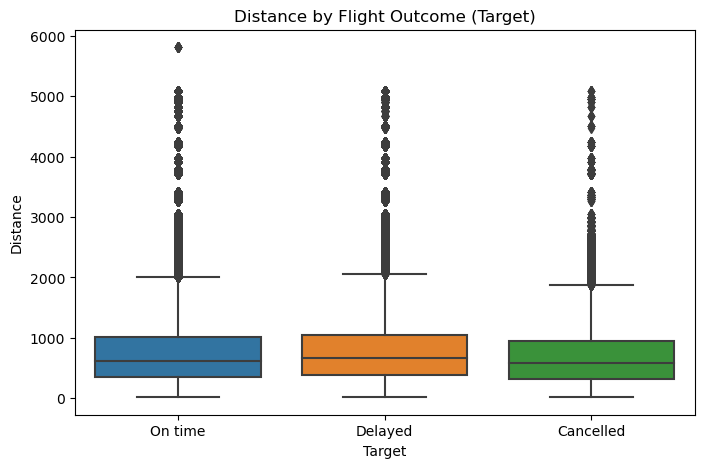

In [90]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="target",
    y="Distance"
)

plt.title("Distance by Flight Outcome (Target)")
plt.xlabel("Target")
plt.ylabel("Distance")
plt.show()


Now let's look at the airline correlation

In [92]:
df.Airline.value_counts()

Airline
Southwest Airlines Co.                       5474339
Delta Air Lines Inc.                         3294917
SkyWest Airlines Inc.                        3159683
American Airlines Inc.                       3134117
United Air Lines Inc.                        2354538
Republic Airlines                            1283704
JetBlue Airways                              1106079
Envoy Air                                    1072778
Endeavor Air Inc.                             998224
Comair Inc.                                   957220
Alaska Airlines Inc.                          906259
Spirit Air Lines                              836694
Mesa Airlines Inc.                            749216
Frontier Airlines Inc.                        570452
Allegiant Air                                 489400
Horizon Air                                   471153
Capital Cargo International                   392011
Air Wisconsin Airlines Corp                   380202
ExpressJet Airlines Inc.              

In [93]:
df.Airline.value_counts(normalize=True)

Airline
Southwest Airlines Co.                       0.187517
Delta Air Lines Inc.                         0.112864
SkyWest Airlines Inc.                        0.108231
American Airlines Inc.                       0.107356
United Air Lines Inc.                        0.080652
Republic Airlines                            0.043972
JetBlue Airways                              0.037887
Envoy Air                                    0.036747
Endeavor Air Inc.                            0.034193
Comair Inc.                                  0.032788
Alaska Airlines Inc.                         0.031043
Spirit Air Lines                             0.028660
Mesa Airlines Inc.                           0.025664
Frontier Airlines Inc.                       0.019540
Allegiant Air                                0.016764
Horizon Air                                  0.016139
Capital Cargo International                  0.013428
Air Wisconsin Airlines Corp                  0.013023
ExpressJet Airlines 

In [94]:
pd.crosstab(df.Airline, df.target).sort_values("Cancelled", ascending=True)

target,Cancelled,Delayed,On time
Airline,,,
Cape Air,2,132,1527
Peninsula Airways Inc.,431,779,1573
Virgin America,433,3022,14215
Empire Airlines Inc.,1293,3167,18662
Compass Airlines,1986,25589,127410
Hawaiian Airlines Inc.,3146,27689,279947
Trans States Airlines,6614,35268,119708
"GoJet Airlines, LLC d/b/a United Express",9240,48442,218804
"Commutair Aka Champlain Enterprises, Inc.",11005,58174,190869


In [95]:
pd.crosstab(df.Airline, df.target, normalize=True).sort_values("Cancelled", ascending=True)

target,Cancelled,Delayed,On time
Airline,,,
Cape Air,6.850774e-08,0.000005,0.000052
Peninsula Airways Inc.,1.476342e-05,0.000027,0.000054
Virgin America,1.483193e-05,0.000104,0.000487
Empire Airlines Inc.,4.429025e-05,0.000108,0.000639
Compass Airlines,6.802818e-05,0.000877,0.004364
Hawaiian Airlines Inc.,1.077627e-04,0.000948,0.009589
Trans States Airlines,2.265551e-04,0.001208,0.004100
"GoJet Airlines, LLC d/b/a United Express",3.165058e-04,0.001659,0.007495
"Commutair Aka Champlain Enterprises, Inc.",3.769638e-04,0.001993,0.006538


[Text(0, 0, 'Air Wisconsin Airlines Corp'),
 Text(1, 0, 'Alaska Airlines Inc.'),
 Text(2, 0, 'Allegiant Air'),
 Text(3, 0, 'American Airlines Inc.'),
 Text(4, 0, 'Cape Air'),
 Text(5, 0, 'Capital Cargo International'),
 Text(6, 0, 'Comair Inc.'),
 Text(7, 0, 'Commutair Aka Champlain Enterprises, Inc.'),
 Text(8, 0, 'Compass Airlines'),
 Text(9, 0, 'Delta Air Lines Inc.'),
 Text(10, 0, 'Empire Airlines Inc.'),
 Text(11, 0, 'Endeavor Air Inc.'),
 Text(12, 0, 'Envoy Air'),
 Text(13, 0, 'ExpressJet Airlines Inc.'),
 Text(14, 0, 'Frontier Airlines Inc.'),
 Text(15, 0, 'GoJet Airlines, LLC d/b/a United Express'),
 Text(16, 0, 'Hawaiian Airlines Inc.'),
 Text(17, 0, 'Horizon Air'),
 Text(18, 0, 'JetBlue Airways'),
 Text(19, 0, 'Mesa Airlines Inc.'),
 Text(20, 0, 'Peninsula Airways Inc.'),
 Text(21, 0, 'Republic Airlines'),
 Text(22, 0, 'SkyWest Airlines Inc.'),
 Text(23, 0, 'Southwest Airlines Co.'),
 Text(24, 0, 'Spirit Air Lines'),
 Text(25, 0, 'Trans States Airlines'),
 Text(26, 0, 'United

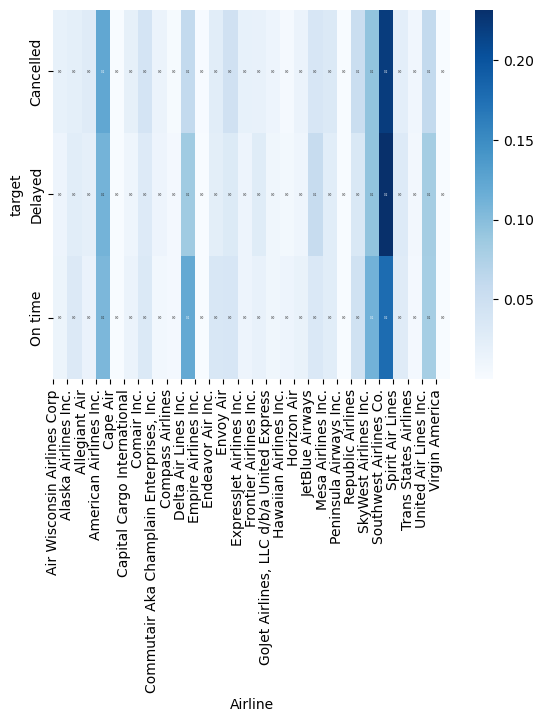

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

ct_norm = pd.crosstab(
    df["target"],
    df["Airline"],
    normalize="index"
)

ax = sns.heatmap(
    ct_norm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    annot_kws={"size": 2}
)

ax.set_xticks(range(len(ct_norm.columns)))
ax.set_xticklabels(ct_norm.columns)



We can see some highly concentrated areas are Southwest Airlines where there are a lot of cancelled and delayed flights. As well as American Airlines and Skywest.

In [97]:
#Hypothesis
## Another thing to consider are hubs for airlines. I.E. American airline hubs are located in Dallas Texas where weather tends to be extreme. This can also be a correlation - weather, airline & cancellations.

Let's look at destination flying to and from!

In [98]:
df.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings,year,target,target_num
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1256.0,0.0,38.0,62.0,59.0,145.0,2018,1,1,23,2,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8928A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,14.0,1211.0,1249.0,7.0,1304,-8.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,3
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1258.0,0.0,36.0,62.0,61.0,145.0,2018,1,1,24,3,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,13.0,1210.0,1246.0,12.0,1304,-6.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,3
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,-9.0,1302.0,0.0,40.0,62.0,69.0,145.0,2018,1,1,25,4,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8836A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,18.0,1211.0,1251.0,11.0,1304,-2.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,3
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,False,False,1202,1150.0,0.0,-12.0,1253.0,0.0,35.0,62.0,63.0,145.0,2018,1,1,26,5,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,17.0,1207.0,1242.0,11.0,1304,-11.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,3
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,False,False,1400,1355.0,0.0,-5.0,1459.0,0.0,36.0,60.0,64.0,145.0,2018,1,1,27,6,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8839E,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1400-1459,17.0,1412.0,1448.0,11.0,1500,-1.0,0.0,-1.0,1500-1559,1,0.0,2018,On time,3


In [99]:
df.Origin.nunique()

388

In [100]:
df.OriginState.unique()

array(['GA', 'AL', 'NY', 'TX', 'VT', 'KY', 'VA', 'NC', 'MO', 'MN', 'WI',
       'MI', 'FL', 'LA', 'IN', 'OH', 'IL', 'TN', 'ME', 'SC', 'ND', 'AR',
       'MA', 'OK', 'WV', 'MS', 'PA', 'NE', 'MD', 'IA', 'NH', 'CT', 'NJ',
       'PR', 'UT', 'CA', 'NV', 'CO', 'WA', 'VI', 'RI', 'OR', 'AZ', 'NM',
       'KS', 'MT', 'ID', 'SD', 'HI', 'WY', 'TT', 'AK', 'DE'], dtype=object)

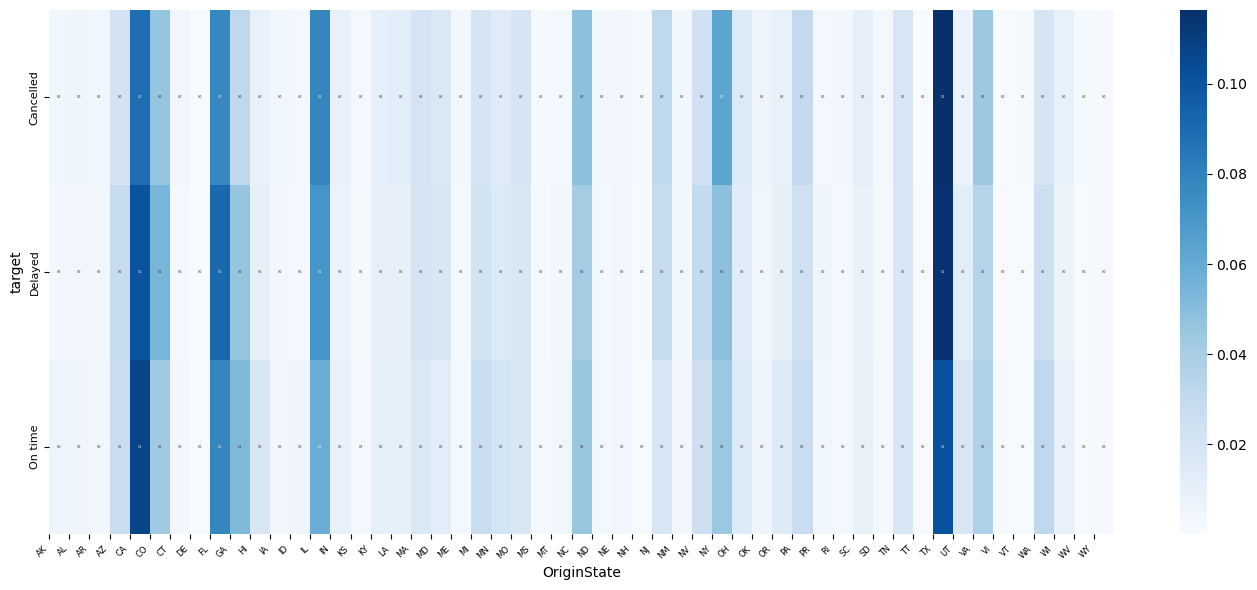

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

ct_norm = pd.crosstab(
    df["target"],
    df["OriginState"],
    normalize="index"
)

ax = sns.heatmap(
    ct_norm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    annot_kws={"size": 2}
)

ax.set_xticks(range(len(ct_norm.columns)))
ax.set_xticklabels(
    ct_norm.columns,
    rotation=45,
    ha="right",
    fontsize=6
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=8
)

plt.tight_layout()
plt.show()

In [102]:
# Most of the flights are coming from CA & TX - so it makes sense why it shows so many in all 4 categories. Highest Cancelled are in CA, CO, L, NC, NY, & TX.

Now that we looked at origin state, lets look at DestState

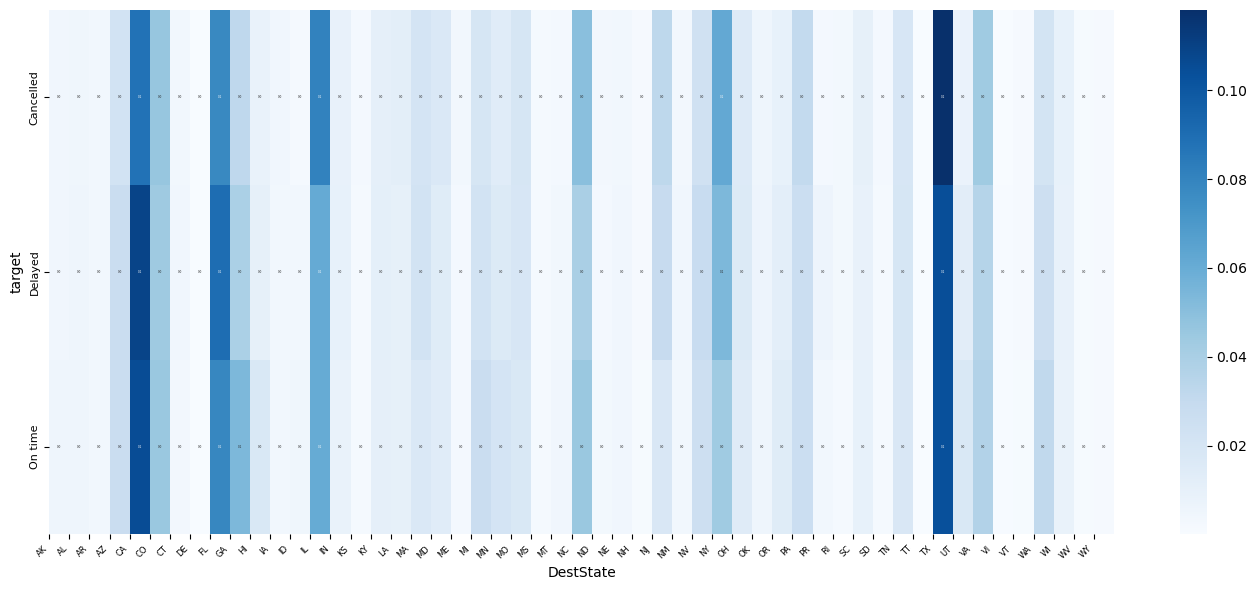

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

ct_norm = pd.crosstab(
    df["target"],
    df["DestState"],
    normalize="index"
)

ax = sns.heatmap(
    ct_norm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    annot_kws={"size": 2}
)

ax.set_xticks(range(len(ct_norm.columns)))
ax.set_xticklabels(
    ct_norm.columns,
    rotation=45,
    ha="right",
    fontsize=6
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=8
)

plt.tight_layout()
plt.show()

Similar patterns there!

Let's see if the time block in which the flight was schedules to leave has a correlation too!


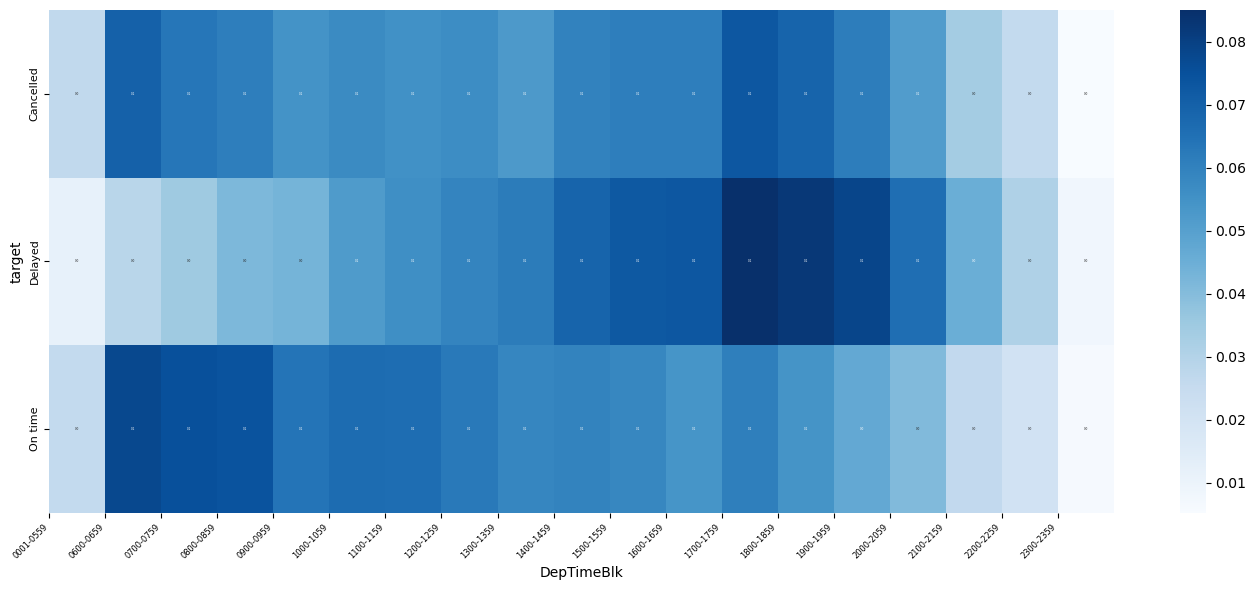

In [104]:
plt.figure(figsize=(14, 6))

ct_norm = pd.crosstab(
    df["target"],
    df["DepTimeBlk"],
    normalize="index"
)

ax = sns.heatmap(
    ct_norm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    annot_kws={"size": 2}
)

ax.set_xticks(range(len(ct_norm.columns)))
ax.set_xticklabels(
    ct_norm.columns,
    rotation=45,
    ha="right",
    fontsize=6
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=8
)

plt.tight_layout()
plt.show()

From this heatmap - 
- we can see that on time flights are highest in the early morning from 6-9am
- on time flights gradually decrease throughout the day
- Delays peak in the mid to late afternoon (2-9pm)

Lets look at distance groups - Distance Intervals, every 250 Miles, for Flight Segment


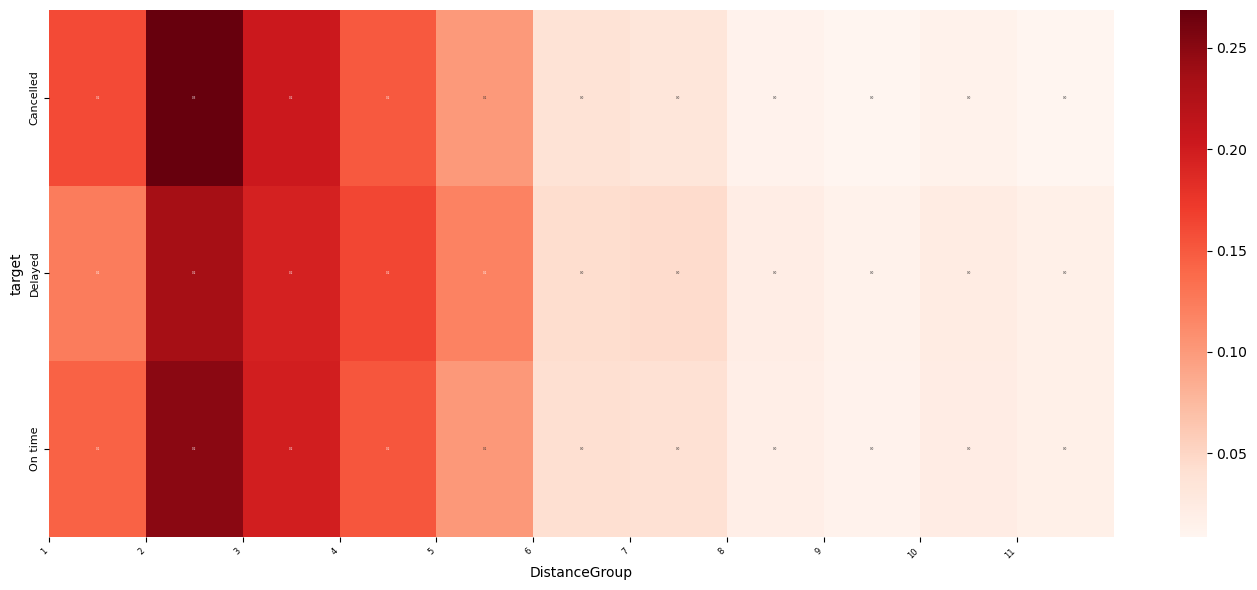

In [105]:
plt.figure(figsize=(14, 6))

ct_norm = pd.crosstab(
    df["target"],
    df["DistanceGroup"],
    normalize="index"
)

ax = sns.heatmap(
    ct_norm,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    annot_kws={"size": 2}
)

ax.set_xticks(range(len(ct_norm.columns)))
ax.set_xticklabels(
    ct_norm.columns,
    rotation=45,
    ha="right",
    fontsize=6
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    fontsize=8
)

plt.tight_layout()
plt.show()

Now let us see a calendar to see times of the year

<Figure size 1600x600 with 0 Axes>

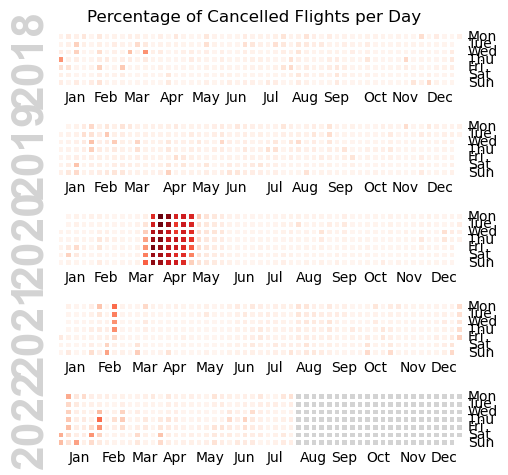

In [106]:
# make sure FlightDate is datetime
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

# flag cancelled flights
df["is_cancelled"] = (df["target"] == "Cancelled").astype(int)

# group by date
daily = df.groupby("FlightDate")["is_cancelled"].agg(["sum", "count"])
daily["pct_cancelled"] = daily["sum"] / daily["count"]


# need a Series with a datetime index
pct_series = daily["pct_cancelled"]
pct_series.index.name = "date"

plt.figure(figsize=(16, 6))
calmap.calendarplot(pct_series, cmap="Reds", fillcolor="lightgrey")

plt.suptitle("Percentage of Cancelled Flights per Day")
plt.show()




<Figure size 1600x600 with 0 Axes>

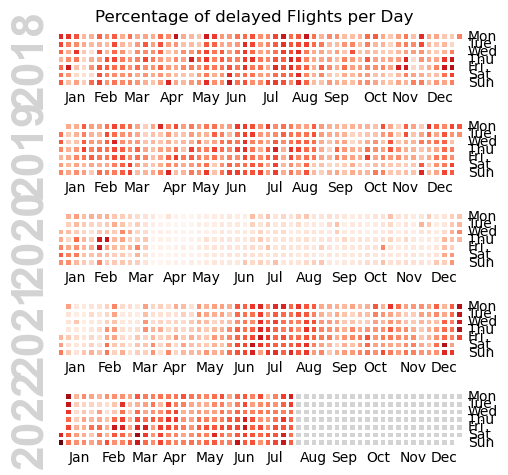

In [107]:
# make sure FlightDate is datetime
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

# flag delayed flights
df["is_delayed"] = (df["target"] == "Delayed").astype(int)

# group by date
daily = df.groupby("FlightDate")["is_delayed"].agg(["sum", "count"])
daily["pct_delayed"] = daily["sum"] / daily["count"]


# need a Series with a datetime index
pct_series = daily["pct_delayed"]
pct_series.index.name = "date"

plt.figure(figsize=(16, 6))
calmap.calendarplot(pct_series, cmap="Reds", fillcolor="lightgrey")

plt.suptitle("Percentage of delayed Flights per Day")
plt.show()

For the year of 2020 - there were lots of cancellelations during the start of the pandemic.

In [108]:
df[df.target == 'Delayed'].OriginCityName.value_counts().sort_values(ascending=False)[0:10]

OriginCityName
Chicago, IL              335983
Denver, CO               242932
Dallas/Fort Worth, TX    212084
Atlanta, GA              208826
New York, NY             178601
Houston, TX              167293
Charlotte, NC            140263
Los Angeles, CA          139934
Newark, NJ               133613
Washington, DC           132377
Name: count, dtype: int64

In [109]:
df.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings,year,target,target_num,is_cancelled,is_delayed
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1256.0,0.0,38.0,62.0,59.0,145.0,2018,1,1,23,2,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8928A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,14.0,1211.0,1249.0,7.0,1304,-8.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,3,0,0
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1258.0,0.0,36.0,62.0,61.0,145.0,2018,1,1,24,3,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,13.0,1210.0,1246.0,12.0,1304,-6.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,3,0,0
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,-9.0,1302.0,0.0,40.0,62.0,69.0,145.0,2018,1,1,25,4,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8836A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,18.0,1211.0,1251.0,11.0,1304,-2.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,3,0,0
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,False,False,1202,1150.0,0.0,-12.0,1253.0,0.0,35.0,62.0,63.0,145.0,2018,1,1,26,5,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,17.0,1207.0,1242.0,11.0,1304,-11.0,0.0,-1.0,1300-1359,1,0.0,2018,On time,3,0,0
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,False,False,1400,1355.0,0.0,-5.0,1459.0,0.0,36.0,60.0,64.0,145.0,2018,1,1,27,6,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8839E,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1400-1459,17.0,1412.0,1448.0,11.0,1500,-1.0,0.0,-1.0,1500-1559,1,0.0,2018,On time,3,0,0


In [111]:
# Are there certain routes/planes that are more likely to get delayed?
df[df.target == 'Delayed'].Flight_Number_Marketing_Airline.value_counts().sort_values(ascending=False)[0:10]

Flight_Number_Marketing_Airline
706    2324
665    2152
679    2140
403    2095
711    2074
678    2067
61     2037
352    2032
566    2018
801    2017
Name: count, dtype: int64

In [112]:
# Are there certain routes/planes that are more likely to get cancelled?
df[df.target == 'Cancelled'].Flight_Number_Marketing_Airline.value_counts().sort_values(ascending=False)[0:10]

Flight_Number_Marketing_Airline
16      346
657     327
676     323
1202    309
347     300
2134    299
679     294
678     293
2101    292
2001    286
Name: count, dtype: int64

In [113]:
# Other ideas
# - Look at 2020 to see if we should exclude it. Does this skew a lot of the data after looking at the calendar
# - weather data
# - For model, we can create features that are binary depending on EDA (i.e. 1/0 weekend or weekday, january/feb/winter, etc.)